## Figure 4E
For each remote interval, find if it is chosen or no.

In [1]:
### For each remote arm representation, calculate the cos(animal_head, arm)

In [3]:
%reload_ext autoreload
%autoreload 2

In [4]:
import pandas as pd
import numpy as np
import xarray as xr
from scipy import stats
from scipy import linalg
import os
import pickle
import matplotlib.pyplot as plt

In [5]:
from spyglass.shijiegu.changeOfMind_figures.figure4d import find_choice_animal, trial_to_features
from spyglass.shijiegu.Analysis_SGU import ChangeofMind

[2025-12-31 14:35:13,090][INFO]: DataJoint 0.14.4 connected to shijiegu-alt@lmf-db.cin.ucsf.edu:3306
[14:35:24][WARNING] Spyglass: Deprecation: this class has been moved out of spyglass.common.common_position
	TrackGraph -> spyglass.linearization.v0.main.TrackGraph
Please use the new location.
	TrackGraph -> spyglass.linearization.v0.main.TrackGraph
Please use the new location.
[14:35:24][WARNING] Spyglass: Deprecation: this class has been moved out of spyglass.common.common_position
	TrackGraph -> spyglass.linearization.v0.main.TrackGraph
Please use the new location.
	TrackGraph -> spyglass.linearization.v0.main.TrackGraph
Please use the new location.
[14:35:24][WARNING] Spyglass: Deprecation: this class has been moved out of spyglass.common.common_position
	TrackGraph -> spyglass.linearization.v0.main.TrackGraph
Please use the new location.
	TrackGraph -> spyglass.linearization.v0.main.TrackGraph
Please use the new location.
[14:35:24][WARNING] Spyglass: Deprecation: this class has b

In [6]:
from spyglass.shijiegu.changeOfMind import nodes
from spyglass.shijiegu.decodeHelpers import session2position_name
from spyglass.shijiegu.changeOfMind_remote import do_GLM_subprocess
from spyglass.shijiegu.changeOfMind_remote_interval import save_remote_animal, load_remote_animal

In [7]:
def return_save_name(animal, encoding_set, classifier_param_name, d1, d2, proportion = 0.1, use_1d = 1):
    save_name = f'{animal.lower()}_{encoding_set}_{classifier_param_name}_{d1}_{d2}_p{proportion}_use1d{use_1d}_remoteGLM'
    return save_name

In [8]:
def make_result_df(model_fit, feature_names = ["constant", "previous", "previously_rewarded", "future", "future_correct"]):
    conf_int = model_fit.conf_int(alpha=0.05) # 95% confidence interval
    coefs = model_fit.params
    
    # Create a DataFrame for easier plotting (optional but good practice)
    results_df = pd.DataFrame({
            'coef': coefs,
            'lower_ci': conf_int[:, 0],
            'upper_ci': conf_int[:, 1]
        }, index=feature_names) # Adjust index names as per your model

    return results_df

In [9]:
list_of_days_animals = {}
encoding_set_animals = {}
classifier_param_name_animals = {}
seq_animals = {}
success_animal = {}

animal = "molly"
list_of_days_animals[animal]  = ['20220416','20220417','20220418','20220419','20220420']
encoding_set_animals[animal]  = '2Dheadspeed_above_4'
classifier_param_name_animals[animal] = 'default_decoding_gpu_4armMaze'
seq_animals[animal] = 'seq2'

animal = "lewis"
list_of_days_animals[animal] = ['20240105','20240106','20240107','20240108','20240109',
                 '20240110']
encoding_set_animals[animal] = '2Dheadspeed_above_4'
classifier_param_name_animals[animal] = 'default_decoding_gpu_4armMaze'
seq_animals[animal] = 'rev2'

animal = "eliot"
list_of_days_animals[animal] = ['20221018','20221019','20221020','20221021','20221022','20221023','20221024','20221025','20221026']
encoding_set_animals[animal] = '2Dheadspeed_above_4_andlowmua'
classifier_param_name_animals[animal] = 'default_decoding_gpu_4armMaze'
seq_animals[animal] = 'seq2'

animal = 'julio'
list_of_days_animals[animal] = ['20230731','20230801','20230802','20230803','20230804',
                 '20230805','20230806','20230807','20230808','20230809','20230810','20230811']

encoding_set_animals[animal] = '2Dheadspeed_above_4'
classifier_param_name_animals[animal] = 'default_decoding_gpu_4armMaze'
seq_animals[animal] = 'seq2'

animal = 'klein'
list_of_days_animals[animal]  = ['20231101','20231102','20231103','20231104','20231105',
                 '20231106','20231107','20231108','20231109']#'20231111']
encoding_set_animals[animal] = '2Dheadspeed_above_4'
classifier_param_name_animals[animal] = 'default_decoding_gpu_4armMaze'
seq_animals[animal] = 'rev2'

In [2]:
proportion = 0.1
use_1d = 1

In [98]:
tally_dict

[21:34:44][WARNING] Spyglass: Deprecation: this class has been moved out of spyglass.common.common_position
	TrackGraph -> spyglass.linearization.v0.main.TrackGraph
Please use the new location.
[21:34:44][WARNING] Spyglass: Deprecation: this class has been moved out of spyglass.common.common_position
	TrackGraph -> spyglass.linearization.v0.main.TrackGraph
Please use the new location.
[21:34:44][WARNING] Spyglass: Deprecation: this class has been moved out of spyglass.common.common_position
	TrackGraph -> spyglass.linearization.v0.main.TrackGraph
Please use the new location.
[21:34:44][WARNING] Spyglass: Deprecation: this class has been moved out of spyglass.common.common_position
	TrackGraph -> spyglass.linearization.v0.main.TrackGraph
Please use the new location.


{('julio20230731_.nwb',
  '02_Seq2Session1',
  22): [(0, array([1.69082471e+09, 1.69082471e+09]), 0)],
 ('julio20230731_.nwb',
  '04_Seq2Session2',
  12): [(0, array([1.69082897e+09, 1.69082897e+09]), 1)],
 ('julio20230731_.nwb',
  '04_Seq2Session2',
  15): [(0, array([1.69082907e+09, 1.69082907e+09]), 0),
  (0, array([1.69082907e+09, 1.69082907e+09]), 1)],
 ('julio20230801_.nwb',
  '06_Seq2Session3',
  11): [(0, array([1.69092239e+09, 1.69092239e+09]), 0), (0,
   array([1.69092239e+09, 1.69092239e+09]),
   3), (0, array([1.69092239e+09, 1.69092239e+09]), 4)],
 ('julio20230802_.nwb',
  '04_Seq2Session2',
  70): [(0, array([1.69100881e+09, 1.69100881e+09]), 2)],
 ('julio20230802_.nwb',
  '06_Seq2Session3',
  51): [(0, array([1.69101276e+09, 1.69101276e+09]), 0)],
 ('julio20230803_.nwb',
  '08_Seq2Session4',
  22): [(0, array([1.69109971e+09, 1.69109971e+09]), 3)],
 ('julio20230803_.nwb',
  '08_Seq2Session4',
  51): [(0, array([1.69110061e+09, 1.69110061e+09]), 0),
  (0, array([1.6911006

### For each animal, tally remote features and then do GLM

In [99]:
success = {}
for animal in ["molly","eliot","lewis","klein","julio"]:
    tally_dict = find_choice_animal(animal, list_of_days_animals[animal],
            encoding_set_animals[animal],
            classifier_param_name_animals[animal],
            proportion = proportion, use_1d = use_1d)
    features_all, response_all = trial_to_features(tally_dict, seq_animals[animal], proportion = 0.1)
    # the 4 features are: "previous", "previously_rewarded", "future", "future_correct"
    
    data = {}
    data["features_all"] = features_all
    data["response_all"] = response_all
    data["tally_dict"] = tally_dict
    output_folder = '/stelmo/shijie/change_of_mind_analysis/figure4/'
    save_name = return_save_name(animal, encoding_set_animals[animal], classifier_param_name_animals[animal],
                                list_of_days_animals[animal][0], list_of_days_animals[animal][1], proportion = 0.1, use_1d = 1)
    
    file_path = output_folder + save_name + '.pkl'
    with open(file_path, 'wb') as file:
        print("data saved to " + file_path)
        pickle.dump(data, file, protocol=pickle.HIGHEST_PROTOCOL)
    success[animal] = 1

[2025-11-08 21:44:43,900][WARNING]: Skipped checksum for file with hash: 3f27d121-a937-64f6-e6d4-0aed06ef3b0d, and path: /stelmo/nwb/analysis/molly20220417/molly20220417_71PDJ5ONHN.nwb


Successfully loaded data from '/stelmo/shijie/change_of_mind_analysis/figure4/molly_2Dheadspeed_above_4_default_decoding_gpu_4armMaze_20220416_20220420_p0.1_use1d1.pkl':


[21:44:52][WARNING] Spyglass: Deprecation: this class has been moved out of spyglass.common.common_position
	IntervalLinearizedPosition -> spyglass.linearization.v0.main.IntervalLinearizedPosition
Please use the new location.
[2025-11-08 21:44:53,019][WARNING]: Skipped checksum for file with hash: 7cdac611-fb1b-a41a-6b56-f5246b5dc7ff, and path: /stelmo/nwb/analysis/molly20220417_L7FHCAMFWW.nwb
[2025-11-08 21:44:53,034][WARNING]: Skipped checksum for file with hash: fdefdbdb-acc7-51e0-75c7-6c333dd20634, and path: /stelmo/nwb/analysis/molly20220417/molly20220417_YGL9VLLBAV.nwb
[2025-11-08 21:44:53,056][WARNING]: Skipped checksum for file with hash: 7cdac611-fb1b-a41a-6b56-f5246b5dc7ff, and path: /stelmo/nwb/analysis/molly20220417_L7FHCAMFWW.nwb
[2025-11-08 21:44:53,063][WARNING]: Skipped checksum for file with hash: 7cdac611-fb1b-a41a-6b56-f5246b5dc7ff, and path: /stelmo/nwb/analysis/molly20220417_L7FHCAMFWW.nwb
[2025-11-08 21:44:53,077][WARNING]: Skipped checksum for file with hash: fde

parsing multiple change of mind


[21:45:02][WARNING] Spyglass: Deprecation: this class has been moved out of spyglass.common.common_position
	IntervalLinearizedPosition -> spyglass.linearization.v0.main.IntervalLinearizedPosition
Please use the new location.
[2025-11-08 21:45:02,291][WARNING]: Skipped checksum for file with hash: 646b67b5-fc8d-1d8a-edc8-12ee02ca486c, and path: /stelmo/nwb/analysis/molly20220417_YLQ61DBELB.nwb
[2025-11-08 21:45:02,305][WARNING]: Skipped checksum for file with hash: ff850b27-3a42-14b3-5b37-ec5a9e356cc0, and path: /stelmo/nwb/analysis/molly20220417/molly20220417_2ILN6BMCX7.nwb
[2025-11-08 21:45:02,327][WARNING]: Skipped checksum for file with hash: 646b67b5-fc8d-1d8a-edc8-12ee02ca486c, and path: /stelmo/nwb/analysis/molly20220417_YLQ61DBELB.nwb
[2025-11-08 21:45:02,333][WARNING]: Skipped checksum for file with hash: 646b67b5-fc8d-1d8a-edc8-12ee02ca486c, and path: /stelmo/nwb/analysis/molly20220417_YLQ61DBELB.nwb
[2025-11-08 21:45:02,347][WARNING]: Skipped checksum for file with hash: ff8

...

parsing multiple change of mind


[21:57:31][WARNING] Spyglass: Deprecation: this class has been moved out of spyglass.common.common_position
	IntervalLinearizedPosition -> spyglass.linearization.v0.main.IntervalLinearizedPosition
Please use the new location.
[2025-11-08 21:57:31,790][WARNING]: Skipped checksum for file with hash: 24b04993-4c9b-f12d-802f-7957e5ecfa02, and path: /stelmo/nwb/analysis/klein20231111/klein20231111_5LNUC3A4OP.nwb
[2025-11-08 21:57:31,811][WARNING]: Skipped checksum for file with hash: 24b04993-4c9b-f12d-802f-7957e5ecfa02, and path: /stelmo/nwb/analysis/klein20231111/klein20231111_5LNUC3A4OP.nwb
[2025-11-08 21:57:31,817][WARNING]: Skipped checksum for file with hash: 24b04993-4c9b-f12d-802f-7957e5ecfa02, and path: /stelmo/nwb/analysis/klein20231111/klein20231111_5LNUC3A4OP.nwb
[2025-11-08 21:57:31,948][WARNING]: Skipped checksum for file with hash: 679bb7f7-228d-a221-bab2-61da9d413357, and path: /stelmo/nwb/analysis/klein20231111/klein20231111_GBUVKP1SCA.nwb
[21:57:40][WARNING] Spyglass: Depr

data saved to /stelmo/shijie/change_of_mind_analysis/figure4/klein_2Dheadspeed_above_4_default_decoding_gpu_4armMaze_20231101_20231102_p0.1_use1d1_remoteGLM.pkl
Successfully loaded data from '/stelmo/shijie/change_of_mind_analysis/figure4/julio_2Dheadspeed_above_4_default_decoding_gpu_4armMaze_20230731_20230811_p0.1_use1d1.pkl':


[21:57:49][WARNING] Spyglass: Deprecation: this class has been moved out of spyglass.common.common_position
	IntervalLinearizedPosition -> spyglass.linearization.v0.main.IntervalLinearizedPosition
Please use the new location.
[2025-11-08 21:57:49,869][WARNING]: Skipped checksum for file with hash: 513175f4-fefc-78cd-be2b-20bcbbe66419, and path: /stelmo/nwb/analysis/julio20230731/julio20230731_36HZ4X4TXC.nwb
[2025-11-08 21:57:49,891][WARNING]: Skipped checksum for file with hash: 513175f4-fefc-78cd-be2b-20bcbbe66419, and path: /stelmo/nwb/analysis/julio20230731/julio20230731_36HZ4X4TXC.nwb
[2025-11-08 21:57:49,896][WARNING]: Skipped checksum for file with hash: 513175f4-fefc-78cd-be2b-20bcbbe66419, and path: /stelmo/nwb/analysis/julio20230731/julio20230731_36HZ4X4TXC.nwb
[2025-11-08 21:57:50,034][WARNING]: Skipped checksum for file with hash: 0eb50806-ca6d-32e9-a55c-f065fd060d4b, and path: /stelmo/nwb/analysis/julio20230731/julio20230731_MV3LNFWHCZ.nwb
[21:57:59][WARNING] Spyglass: Depr

data saved to /stelmo/shijie/change_of_mind_analysis/figure4/julio_2Dheadspeed_above_4_default_decoding_gpu_4armMaze_20230731_20230801_p0.1_use1d1_remoteGLM.pkl


In [100]:
success

{'molly': 1, 'eliot': 1, 'lewis': 1, 'klein': 1, 'julio': 1}

### for debug

In [408]:
animal = "lewis"
list_of_days = ['20240105','20240109',
                 '20240110']
tally_dict = find_choice_animal(animal, list_of_days,
            encoding_set_animals[animal],
            classifier_param_name_animals[animal],
            proportion = proportion, use_1d = use_1d)
features_all, response_all, info_all = trial_to_features(tally_dict, seq_animals[animal],
                                               proportion = 0.1, debug = True)

[2025-10-23 14:36:14,920][WARNING]: Skipped checksum for file with hash: 6d15f446-1984-2674-6897-0e6a64f753db, and path: /stelmo/nwb/analysis/lewis20240105/lewis20240105_DYWTT7D99X.nwb


Successfully loaded data from '/stelmo/shijie/change_of_mind_analysis/figure4/lewis_2Dheadspeed_above_4_default_decoding_gpu_4armMaze_20240105_20240110_p0.1_use1d1.pkl':


[14:36:23][WARNING] Spyglass: Deprecation: this class has been moved out of spyglass.common.common_position
	IntervalLinearizedPosition -> spyglass.linearization.v0.main.IntervalLinearizedPosition
Please use the new location.
	IntervalLinearizedPosition -> spyglass.linearization.v0.main.IntervalLinearizedPosition
Please use the new location.
[2025-10-23 14:36:23,889][WARNING]: Skipped checksum for file with hash: 0f891b0b-3eb3-416a-2ada-3a6529963d90, and path: /stelmo/nwb/analysis/lewis20240105/lewis20240105_9OUQSQKSE7.nwb
[2025-10-23 14:36:23,907][WARNING]: Skipped checksum for file with hash: 0f891b0b-3eb3-416a-2ada-3a6529963d90, and path: /stelmo/nwb/analysis/lewis20240105/lewis20240105_9OUQSQKSE7.nwb
[2025-10-23 14:36:23,912][WARNING]: Skipped checksum for file with hash: 0f891b0b-3eb3-416a-2ada-3a6529963d90, and path: /stelmo/nwb/analysis/lewis20240105/lewis20240105_9OUQSQKSE7.nwb
[2025-10-23 14:36:24,026][WARNING]: Skipped checksum for file with hash: d9c26373-1f9f-0b90-e4d4-ac43

parsing multiple change of mind
parsing multiple change of mind


[14:36:32][WARNING] Spyglass: Deprecation: this class has been moved out of spyglass.common.common_position
	IntervalLinearizedPosition -> spyglass.linearization.v0.main.IntervalLinearizedPosition
Please use the new location.
	IntervalLinearizedPosition -> spyglass.linearization.v0.main.IntervalLinearizedPosition
Please use the new location.
[2025-10-23 14:36:32,807][WARNING]: Skipped checksum for file with hash: 81f05635-320a-3aa8-f94e-87a8c89b9b2c, and path: /stelmo/nwb/analysis/lewis20240105/lewis20240105_V9VFCR92YP.nwb
[2025-10-23 14:36:32,824][WARNING]: Skipped checksum for file with hash: 81f05635-320a-3aa8-f94e-87a8c89b9b2c, and path: /stelmo/nwb/analysis/lewis20240105/lewis20240105_V9VFCR92YP.nwb
[2025-10-23 14:36:32,829][WARNING]: Skipped checksum for file with hash: 81f05635-320a-3aa8-f94e-87a8c89b9b2c, and path: /stelmo/nwb/analysis/lewis20240105/lewis20240105_V9VFCR92YP.nwb
[2025-10-23 14:36:32,910][WARNING]: Skipped checksum for file with hash: 8fca837d-dec5-5610-eb71-c7ec

...

parsing multiple change of mind
parsing multiple change of mind


[14:38:53][WARNING] Spyglass: Deprecation: this class has been moved out of spyglass.common.common_position
	IntervalLinearizedPosition -> spyglass.linearization.v0.main.IntervalLinearizedPosition
Please use the new location.
	IntervalLinearizedPosition -> spyglass.linearization.v0.main.IntervalLinearizedPosition
Please use the new location.
[2025-10-23 14:38:53,945][WARNING]: Skipped checksum for file with hash: 6ba48a1e-2633-a8e4-fe68-928f82eb77e0, and path: /stelmo/nwb/analysis/lewis20240110/lewis20240110_BBPO58S8KF.nwb
[2025-10-23 14:38:53,962][WARNING]: Skipped checksum for file with hash: 6ba48a1e-2633-a8e4-fe68-928f82eb77e0, and path: /stelmo/nwb/analysis/lewis20240110/lewis20240110_BBPO58S8KF.nwb
[2025-10-23 14:38:53,968][WARNING]: Skipped checksum for file with hash: 6ba48a1e-2633-a8e4-fe68-928f82eb77e0, and path: /stelmo/nwb/analysis/lewis20240110/lewis20240110_BBPO58S8KF.nwb
[2025-10-23 14:38:54,062][WARNING]: Skipped checksum for file with hash: 7f5489c8-88f7-858f-7260-a1d1

parsing multiple change of mind
parsing multiple change of mind


[14:39:02][WARNING] Spyglass: Deprecation: this class has been moved out of spyglass.common.common_position
	IntervalLinearizedPosition -> spyglass.linearization.v0.main.IntervalLinearizedPosition
Please use the new location.
	IntervalLinearizedPosition -> spyglass.linearization.v0.main.IntervalLinearizedPosition
Please use the new location.
[2025-10-23 14:39:02,723][WARNING]: Skipped checksum for file with hash: 639c2f29-6f35-8eb0-ea11-7ee6be577699, and path: /stelmo/nwb/analysis/lewis20240110/lewis20240110_6K2WVTTBUQ.nwb
[2025-10-23 14:39:02,742][WARNING]: Skipped checksum for file with hash: 639c2f29-6f35-8eb0-ea11-7ee6be577699, and path: /stelmo/nwb/analysis/lewis20240110/lewis20240110_6K2WVTTBUQ.nwb
[2025-10-23 14:39:02,748][WARNING]: Skipped checksum for file with hash: 639c2f29-6f35-8eb0-ea11-7ee6be577699, and path: /stelmo/nwb/analysis/lewis20240110/lewis20240110_6K2WVTTBUQ.nwb


parsing multiple change of mind
parsing multiple change of mind


In [409]:
i = 34
print(response_all[i])
print(features_all[i])
print(info_all[i])
nwb_copy_file_name, session_name, trialID, arm = info_all[i]
 #"previous", "previously_rewarded", "future", "future_correct"

[array(False), array(True), array(False), array(False)]
[[False False False False]
 [False  True False False]
 [ True False False False]
 [False False  True  True]]
('lewis20240109_.nwb', '04_Rev2Session2', 44, nan)


In [401]:
log_df.loc[trialID - 3:trialID]

,timestamp_H,Home,timestamp_O,OuterWellIndex,rewardNum,change_of_mind,CoMMaxProportion,initial_choice,initial_time,proportion_arm1,proportion_arm2,proportion_arm3,proportion_arm4,CoMNum_by_time,CoMNum_by_arm,current,future_H,future_O,past,past_reward
id,,,,,,,,,,,,,,,,,,,,
41,1.704834e+09,1.0,1.704834e+09,4.0,1.0,True,1.000000,3.0,1.704834e+09,0.000000,0.0,1.0,0.0,2,1,4.0,4.0,2.0,1.0,1.0
42,1.704834e+09,1.0,1.704834e+09,2.0,2.0,False,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,0,2.0,2.0,3.0,4.0,1.0
43,1.704834e+09,1.0,1.704834e+09,3.0,1.0,True,0.334493,3.0,1.704834e+09,0.334493,0.0,0.0,0.0,2,1,3.0,3.0,4.0,2.0,2.0
44,1.704834e+09,1.0,1.704834e+09,4.0,2.0,True,0.647582,1.0,1.704834e+09,0.647582,0.0,0.0,0.0,1,1,4.0,4.0,3.0,3.0,2.0


In [394]:

q = {"nwb_file_name": nwb_copy_file_name,
     "epoch":int(session_name[:2]),
     "proportion":str(proportion)}
                
log_df = ChangeofMind().fetch1_dataframe(q)


[2025-10-23 14:25:26,460][WARNING]: Skipped checksum for file with hash: ee40e5ba-9fdc-90c3-3766-1c50274b6c99, and path: /stelmo/nwb/analysis/lewis20240109/lewis20240109_NQZAQGZEO4.nwb


timestamp_H         1704832839.939447
Home                              1.0
timestamp_O         1704832852.365493
OuterWellIndex                    1.0
rewardNum                         2.0
change_of_mind                  False
CoMMaxProportion                  NaN
initial_choice                    NaN
initial_time                      NaN
proportion_arm1                   NaN
proportion_arm2                   NaN
proportion_arm3                   NaN
proportion_arm4                   NaN
CoMNum_by_time                      0
CoMNum_by_arm                       0
current                           1.0
future_H                          1.0
future_O                          2.0
past                              3.0
past_reward                       3.0
Name: 10, dtype: object

### debug end

### load data, do GLM, then plot coefficients

In [20]:
features_all

[array([[ True, False, False, False],
        [False, False, False, False],
        [False, False,  True,  True],
        [False,  True, False, False]]),
 array([[False, False, False,  True],
        [False, False, False, False],
        [ True,  True, False, False],
        [False, False,  True, False]]),
 array([[ True,  True, False, False],
        [False, False,  True,  True],
        [False, False, False, False],
        [False, False, False, False]]),
 array([[False,  True, False, False],
        [False, False,  True,  True],
        [False, False, False, False],
        [ True, False, False, False]]),
 array([[False,  True, False, False],
        [False, False,  True,  True],
        [ True, False, False, False],
        [False, False, False, False]]),
 array([[False,  True, False, False],
        [ True, False, False,  True],
        [False, False,  True, False],
        [False, False, False, False]]),
 array([[ True,  True, False, False],
        [False, False,  True,  True],


In [21]:
response_all

[[array(False), array(False), array(True), array(True)],
 [array(False), array(False), array(True), array(False)],
 [array(True), array(True), array(False), array(False)],
 [array(False), array(True), array(False), array(False)],
 [array(False), array(False), array(True), array(False)],
 [array(False), array(False), array(True), array(False)],
 [array(True), array(False), array(True), array(False)],
 [array(False), array(False), array(True), array(False)],
 [array(False), array(False), array(True), array(True)],
 [array(True), array(False), array(True), array(False)],
 [array(False), array(False), array(False), array(True)],
 [array(False), array(True), array(True), array(False)],
 [array(True), array(False), array(False), array(False)],
 [array(False), array(True), array(False), array(False)],
 [array(False), array(True), array(False), array(False)],
 [array(False), array(True), array(False), array(False)],
 [array(False), array(True), array(False), array(False)],
 [array(False), arra

### Each rat individually

lewis_2Dheadspeed_above_4_default_decoding_gpu_4armMaze_20240105_20240106_p0.1_use1d1_remoteGLM
                 Generalized Linear Model Regression Results                  
Dep. Variable:                      y   No. Observations:                  224
Model:                            GLM   Df Residuals:                      217
Model Family:                Binomial   Df Model:                            6
Link Function:                  Logit   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -117.18
Date:                Sat, 08 Nov 2025   Deviance:                       234.36
Time:                        22:03:39   Pearson chi2:                     222.
No. Iterations:                     5   Pseudo R-squ. (CS):             0.1396
Covariance Type:            nonrobust                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------

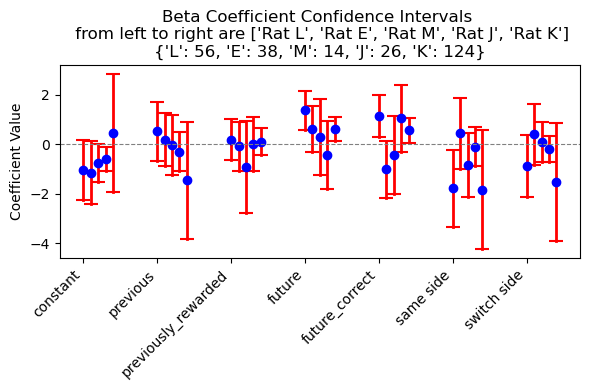

In [101]:
# Plotting
fig, ax = plt.subplots(figsize=(6, 4))
feature_names = ["constant", "previous", "previously_rewarded", "future", "future_correct","same side","switch side"]

animal_ind = 0
animals = ["lewis","eliot","molly","julio","klein"]
num_of_com = {} #number of change of mind considered
for animal in animals:
    output_folder = '/stelmo/shijie/change_of_mind_analysis/figure4/'
    save_name = return_save_name(animal, encoding_set_animals[animal], classifier_param_name_animals[animal],
                                list_of_days_animals[animal][0], list_of_days_animals[animal][1], proportion = 0.1, use_1d = 1)
    print(save_name)
    file_path = output_folder + save_name + '.pkl'
    with open(file_path, 'rb') as file:
        data = pickle.load(file)

    features_all, response_all = data["features_all"], data["response_all"]

    # GLM process
    animal_category = [a == animal for a in animals]
    
    X = np.vstack(features_all).astype("int") #reshape
    Y = np.vstack([np.array(r).reshape((-1,1))for r in response_all]) #reshape
    model = do_GLM_subprocess(np.hstack((X,Y)))
    print(model['fit'].summary())
    num_of_com[animal[0].upper()] = int(np.shape(X)[0] / 4)

    # plot
    results_df = make_result_df(model['fit'], feature_names)
    
    # Plot coefficients as points
    x = np.arange(len(results_df.index)) + 0.1*animal_ind
    y = results_df['coef']
    ax.scatter(x, results_df['coef'], color='blue', zorder=2, label='Coefficient Estimates')
    
    # Plot confidence intervals as error bars or lines
    row_ind = 0
    for i, row in results_df.iterrows():
        ax.plot([row_ind + 0.1*animal_ind, row_ind + 0.1*animal_ind], [row['lower_ci'], row['upper_ci']], color='red', linestyle='-', linewidth=2, zorder=1)
        
        ax.scatter(row_ind + 0.1*animal_ind, row['lower_ci'], marker='_', s=100, color='red', zorder=1)
        ax.scatter(row_ind + 0.1*animal_ind, row['upper_ci'], marker='_', s=100, color='red', zorder=1)
        row_ind += 1
    
    
    animal_ind += 1

ax.axhline(y=0, color='gray', linestyle='--', linewidth=0.8) # Reference line at zero
ax.set_ylabel('Coefficient Value')
rat_names = ['Rat '+a[0].upper() for a in animals]
ax.set_title(f'Beta Coefficient Confidence Intervals \n from left to right are {rat_names}\n{num_of_com}')

ax.set_xticks(np.arange(len(results_df.index)))
ax.set_xticklabels(feature_names)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [102]:
num_of_com

{'L': 56, 'E': 38, 'M': 14, 'J': 26, 'K': 124}

#### scatter plot

In [103]:
"previous", "previously_rewarded", "future", "future_correct"

('previous', 'previously_rewarded', 'future', 'future_correct')

In [109]:
def return_probabilities(X,Y):
    chosen = np.sum(Y[X[:,2] == 1]) / len(Y[X[:,2] == 1]) #chosen
    unchosen = np.sum(Y[X[:,2] == 0]) / len(Y[X[:,2] == 0]) #unchosen
    previous = np.sum(Y[X[:,0] == 1]) / len(Y[X[:,0] == 1]) #previous
    previous_reward = np.sum(Y[X[:,1] == 1]) / len(Y[X[:,1] == 1]) #previously_rewarded
    future_correct = np.sum(Y[X[:,3] == 1]) / len(Y[X[:,3] == 1]) #future correct
    
    same_side = np.sum(Y[X[:,4] == 1]) / len(Y[X[:,4] == 1]) #future correct
    switch_side = np.sum(Y[X[:,5] == 1]) / len(Y[X[:,5] == 1]) #future correct
    return chosen, unchosen, previous, previous_reward, future_correct, same_side, switch_side

In [105]:
import seaborn as sns
from spyglass.shijiegu.changeOfMind import color_by_rat

In [106]:
def return_p_value(rand, q):
    return np.sum(rand >= q) / len(rand)

In [107]:
#chosen_rand

eliot_2Dheadspeed_above_4_andlowmua_default_decoding_gpu_4armMaze_20221018_20221019_p0.1_use1d1_remoteGLM
p value for future: 0.36
p value for previously rewarded: 0.65
lewis_2Dheadspeed_above_4_default_decoding_gpu_4armMaze_20240105_20240106_p0.1_use1d1_remoteGLM
p value for future: 0.0
p value for previously rewarded: 0.35
molly_2Dheadspeed_above_4_default_decoding_gpu_4armMaze_20220416_20220417_p0.1_use1d1_remoteGLM
p value for future: 0.52
p value for previously rewarded: 0.98
julio_2Dheadspeed_above_4_default_decoding_gpu_4armMaze_20230731_20230801_p0.1_use1d1_remoteGLM
p value for future: 0.29
p value for previously rewarded: 0.74
klein_2Dheadspeed_above_4_default_decoding_gpu_4armMaze_20231101_20231102_p0.1_use1d1_remoteGLM
p value for future: 0.0
p value for previously rewarded: 0.73
number of observations by rat:
{'L': 56, 'E': 38, 'M': 14, 'J': 26, 'K': 124}


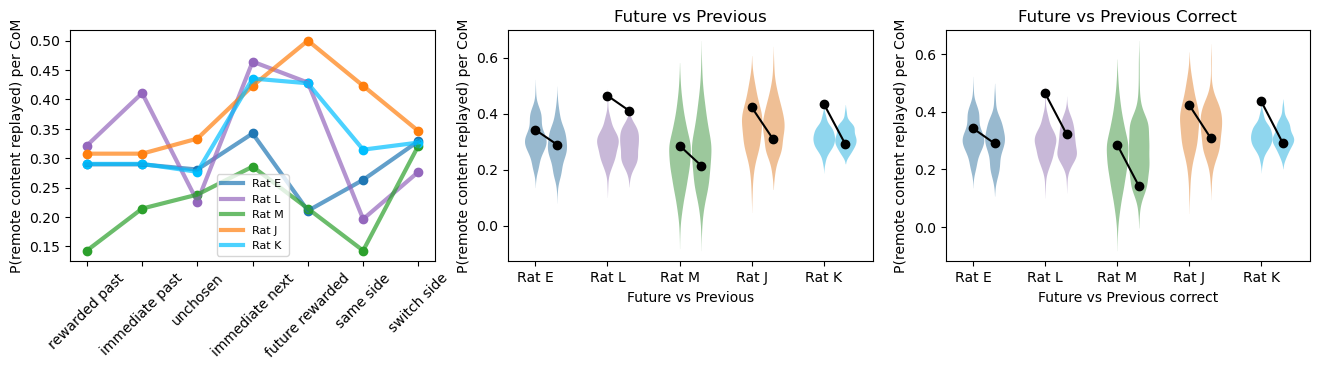

In [112]:
B = 100
fig, axes = plt.subplots(1,3, figsize=(16, 3))

animals = ["eliot","lewis","molly","julio","klein"]

future_all = []
prev_reward_all = []

ax = axes[0]
animal_ind = 0
for animal in animals:
    output_folder = '/stelmo/shijie/change_of_mind_analysis/figure4/'
    save_name = return_save_name(animal, encoding_set_animals[animal], classifier_param_name_animals[animal],
                                    list_of_days_animals[animal][0], list_of_days_animals[animal][1], proportion = 0.1, use_1d = 1)
    print(save_name)
    file_path = output_folder + save_name + '.pkl'
    with open(file_path, 'rb') as file:
            data = pickle.load(file)
    
    features_all, response_all = data["features_all"], data["response_all"]
    X = np.vstack(features_all).astype("int") #reshape
    Y = np.vstack([np.array(r).reshape((-1,1))for r in response_all]) #reshape
    Y = Y.ravel()
    
    # data
    chosen, unchosen, previous, previous_reward, future_correct, same_side, switch_side = return_probabilities(X,Y)
    # CI
    (chosen_rand, unchosen_rand, previous_rand, previous_reward_rand, future_correct_rand,
     same_side_rand, switch_side_rand) = ([], [], [], [], [], [], [])
    for n in range(B):
        Y_permute = np.random.permutation(Y)
        chosen_, unchosen_, previous_, previous_reward_, future_correct_, same_side_, switch_side_ = return_probabilities(X,Y_permute)
        chosen_rand.append(chosen_)
        unchosen_rand.append(unchosen_)
        previous_rand.append(previous_)
        previous_reward_rand.append(previous_reward_)
        future_correct_rand.append(future_correct_)
        same_side_rand.append(same_side_)
        switch_side_rand.append(switch_side_)
    #violin_dict = {"0": chosen_rand, "1": previous_rand}
    
    xs = np.array([0,0.3]) + (animal_ind)
    df = pd.DataFrame()
    df['Future vs Previous'] = np.repeat(xs, B)
    df['values'] = np.hstack((np.array(chosen_rand).reshape((-1,1)),np.array(previous_rand).reshape((-1,1)))).T.flatten()
    sns.violinplot(data=df, x='Future vs Previous', y='values', ax = axes[1], color = color_by_rat[animal],
               native_scale=True, orient='vertical', inner=None, linewidth=0, width=1, alpha = 0.5)

    #ax_ = sns.violinplot(violin_dict, width=0.1, ax = axes[1], alpha = 0.2, color = "C"+str(animal_ind))
    
    ax.scatter([0,1,2,3,4,5,6],[previous_reward, previous, unchosen, chosen, future_correct, same_side, switch_side], color = color_by_rat[animal])
    ax.plot([0,1,2,3,4,5,6],[previous_reward, previous, unchosen, chosen, future_correct, same_side, switch_side],
            label = 'Rat '+str(animal[0]).upper(),
            color = color_by_rat[animal],
            linewidth = 3,
            alpha = 0.7,
           )

    axes[1].scatter(np.array([0,0.3]) + (animal_ind) ,[chosen,previous],color = 'k')
    axes[1].plot(np.array([0,0.3]) + (animal_ind) ,[chosen,previous] ,'k')
    #axes[1].axhline(np.mean(Y),color = 'C'+str(animal_ind))
    
    axes[1].set_ylabel("P(remote content replayed) per CoM")


    xs = np.array([0,0.3]) + (animal_ind)
    df = pd.DataFrame()
    df['Future vs Previous correct'] = np.repeat(xs, B)
    df['values'] = np.hstack((np.array(chosen_rand).reshape((-1,1)),np.array(previous_reward_rand).reshape((-1,1)))).T.flatten()
    sns.violinplot(data=df, x='Future vs Previous correct', y='values', ax = axes[2], color = color_by_rat[animal],
               native_scale=True, orient='vertical', inner=None, linewidth=0, width=1, alpha = 0.5)

    axes[2].scatter(np.array([0,0.3]) + (animal_ind) ,[chosen,previous_reward],color = 'k')
    axes[2].plot(np.array([0,0.3]) + (animal_ind) ,[chosen,previous_reward] ,'k')
    axes[2].set_ylabel("P(remote content replayed) per CoM")

    print(f"p value for future: {return_p_value(chosen_rand, chosen)}")
    print(f"p value for previously rewarded: {return_p_value(previous_reward_rand, previous_reward)}")
    future_all.append(chosen)
    prev_reward_all.append(previous_reward)

    animal_ind += 1


ax.set_xticks([0,1,2,3,4,5,6])
ax.set_xticklabels(["rewarded past", "immediate past","unchosen",  "immediate next", "future rewarded", "same side", "switch side"],rotation = 45)
ax.set_ylabel("P(remote content replayed) per CoM")

axes[1].set_xticks(np.arange(animal_ind))
axes[1].set_xticklabels(["Rat " + a[0].upper() for a in animals])
axes[1].set_title("Future vs Previous")

axes[2].set_xticks(np.arange(animal_ind))
axes[2].set_xticklabels(["Rat " + a[0].upper() for a in animals])
axes[2].set_title("Future vs Previous Correct")
axes[0].legend(fontsize=8)

print("number of observations by rat:")
print(num_of_com)

plt.savefig(f'theta_remote_content_choice_all_animals.pdf',dpi=300,bbox_inches='tight')

### Merge rats. Mixed logistic regression

In [55]:
import numpy.matlib as ml
from scipy.stats import ranksums
from scipy.stats import fisher_exact
import starbars
import statsmodels.api as sm

In [113]:
feature_names = ["previous", "previously_rewarded", "future", "future_correct", "same side", "switch side"]

animal_ind = 0
animals = ["lewis","eliot","molly","julio","klein"]

GLM_x = []
GLM_y = []
for animal in animals:
    output_folder = '/stelmo/shijie/change_of_mind_analysis/figure4/'
    save_name = return_save_name(animal, encoding_set_animals[animal], classifier_param_name_animals[animal],
                                list_of_days_animals[animal][0], list_of_days_animals[animal][1], proportion = 0.1, use_1d = 1)
    print(save_name)
    file_path = output_folder + save_name + '.pkl'
    with open(file_path, 'rb') as file:
        data = pickle.load(file)

    features_all, response_all = data["features_all"], data["response_all"]

    # GLM process
    X = np.vstack(features_all).astype("int") #reshape
    
    animal_category = np.array([a == animal for a in animals]).reshape((1,-1))
    X_animal_category = ml.repmat(animal_category, np.shape(X)[0], 1)
    X = np.hstack((X_animal_category, X))
    
    Y = np.vstack([np.array(r).reshape((-1,1))for r in response_all]) #reshape

    GLM_x.append(X)
    GLM_y.append(Y)
    
GLM_x = np.vstack(GLM_x)
GLM_y = np.vstack(GLM_y)

lewis_2Dheadspeed_above_4_default_decoding_gpu_4armMaze_20240105_20240106_p0.1_use1d1_remoteGLM
eliot_2Dheadspeed_above_4_andlowmua_default_decoding_gpu_4armMaze_20221018_20221019_p0.1_use1d1_remoteGLM
molly_2Dheadspeed_above_4_default_decoding_gpu_4armMaze_20220416_20220417_p0.1_use1d1_remoteGLM
julio_2Dheadspeed_above_4_default_decoding_gpu_4armMaze_20230731_20230801_p0.1_use1d1_remoteGLM
klein_2Dheadspeed_above_4_default_decoding_gpu_4armMaze_20231101_20231102_p0.1_use1d1_remoteGLM


In [118]:
feature_dict = {f"Rat {animals[animal_ind][0].upper()}":GLM_x[:,animal_ind] for animal_ind in range(len(animals))}
feature_dict["immediate past"] = GLM_x[:,len(animals)]
feature_dict["rewarded past"] = GLM_x[:,(len(animals)+1)]
feature_dict["immediate next"] = GLM_x[:,(len(animals)+2)]
feature_dict["correct future"] = GLM_x[:,(len(animals)+3)]
feature_dict["same side"] = GLM_x[:,(len(animals)+4)]
feature_dict["switch side"] = GLM_x[:,(len(animals)+5)]

X = pd.DataFrame(feature_dict)
X = sm.add_constant(X)
y = GLM_y

"""a) Mixed Linear Effect"""
ols_model = sm.OLS(y,X)
ols_result1 = ols_model.fit()

print("Mixed Linear Effect \n",ols_result1.summary())

"""b) Logistic"""
logistic_model = sm.Logit(y, X)
logistic_result1 = logistic_model.fit()

# 3. View the model summary
print("Mixed Logistics \n",logistic_result1.summary())

Mixed Linear Effect 
                             OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.033
Model:                            OLS   Adj. R-squared:                  0.023
Method:                 Least Squares   F-statistic:                     3.469
Date:                Sat, 08 Nov 2025   Prob (F-statistic):           0.000168
Time:                        22:10:33   Log-Likelihood:                -648.69
No. Observations:                1032   AIC:                             1319.
Df Residuals:                    1021   BIC:                             1374.
Df Model:                          10                                         
Covariance Type:            nonrobust                                         
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
const              0.2

In [119]:
def model2numbers(ols_result):
    coef_names = ols_result.params.keys()
    coef_est = np.array(ols_result.params)
    pvalues = ols_result.pvalues
    CI = ols_result.conf_int(alpha=0.05)
    #yerr = np.vstack((np.array(CI[0]).reshape((1,-1)), np.array(CI[1]).reshape((1,-1)))) # 2 x coefficients

    coef_names_subset_ind = ["Rat" not in name for name in coef_names]
    coef_names = np.array(coef_names)[coef_names_subset_ind]
    coef_est = coef_est[coef_names_subset_ind]
    pvalues = pvalues[coef_names_subset_ind]
    CI = CI.loc[coef_names]

    return ols_result.params, coef_names, coef_est, pvalues, CI#, yerr

7.4799999999999995 0.03
7.4799999999999995 0.03
7.4799999999999995 0.03
7.4799999999999995 0.03
7.4799999999999995 0.03
Fold change of the effect of immediate next is 1.9424647001592545, with 95% bound: (1.3800693647421252, 2.734043090703505)


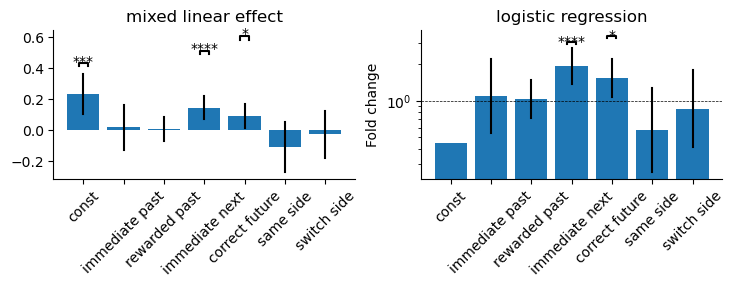

In [120]:
# 4. Create the bar graph using matplotlib

fig, axes = plt.subplots(1,2,figsize=(8, 3.5))

#### axis 0
coef_pd, coef_names, coef_est, pvalues, CI = model2numbers(ols_result1)
axes[0].bar(coef_names, coef_est, error_kw=dict(color='k'))
for coef_name in coef_names:
    axes[0].plot([coef_name,coef_name],[CI.loc[coef_name][0], CI.loc[coef_name][1]], color = 'k')

for coef_ind in range(len(pvalues)):
    pvalue = pvalues[coef_ind]
    if pvalue < 0.05:
        starbars.draw_annotation([(coef_ind, coef_ind, np.round(pvalue, 4))], ax = axes[0])

axes[0].set_xticks(np.arange(len(coef_names)))
axes[0].set_xticklabels(coef_names, rotation=45)
axes[0].set_title("mixed linear effect")
axes[0].spines[['right', 'top']].set_visible(False)


#### axis 1
coef_pd, coef_names, coef_est, pvalues, CI = model2numbers(logistic_result1)
coef_est = np.exp(coef_est)
coef_pd = np.exp(coef_pd)
CI = np.exp(CI)

axes[1].bar(coef_names, coef_est, error_kw=dict(color='k'))
for coef_name in coef_names:
    axes[1].plot([coef_name,coef_name],[CI.loc[coef_name][0], CI.loc[coef_name][1]], color = 'k')

for coef_ind in range(len(pvalues)):
    pvalue = pvalues[coef_ind]
    if pvalue < 0.05:
        starbars.draw_annotation([(coef_ind, coef_ind, np.round(pvalue, 4))], ax = axes[1], color = 'k')

axes[1].set_xticks(np.arange(len(coef_names)))
axes[1].set_xticklabels(coef_names, rotation=45)
axes[1].set_title("logistic regression")
axes[1].set_ylabel("Fold change")
axes[1].axhline(1,linewidth = 0.5,linestyle='dashed', color = 'k')
axes[1].set_yscale('log') 

next_point_est = coef_pd.loc["immediate next"]
next_CI = CI.loc["immediate next"]
print(f"Fold change of the effect of immediate next is {next_point_est}, with 95% bound: {next_CI[0],next_CI[1]}")
axes[1].spines[['right', 'top']].set_visible(False)
fig.tight_layout(pad=3.0, w_pad=0.5, h_pad=1.0) 

plt.savefig(f'theta_remote_content_choice_all_animals_logistic.pdf',dpi=300,bbox_inches='tight')

In [471]:
from scipy import stats
t_statistic, p_value = stats.ttest_rel(future_all,prev_reward_all)
print(p_value)

0.02345904959252356


In [278]:
np.mean(Y[X[:,3] == 0]) #chosen

0.06666666666666667

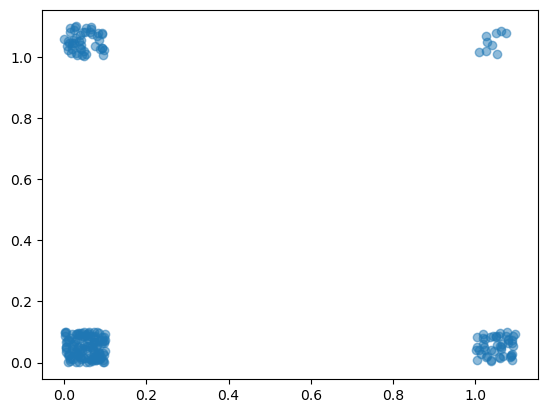

In [273]:
plt.scatter(X[:,1] + np.random.rand(len(X[:,1])) * 0.1,
            Y+ np.random.rand(len(Y)) * 0.1, alpha = 0.5)

### End here

In [ ]:


# Plotting
fig, ax = plt.subplots(figsize=(4, 3))

# Plot coefficients as points
ax.scatter(results_df.index, results_df['coef'], color='blue', zorder=2, label='Coefficient Estimates')

# Plot confidence intervals as error bars or lines
for i, row in results_df.iterrows():
    ax.plot([row.name, row.name], [row['lower_ci'], row['upper_ci']], color='red', linestyle='-', linewidth=2, zorder=1)
    ax.scatter(row.name, row['lower_ci'], marker='_', s=100, color='red', zorder=1)
    ax.scatter(row.name, row['upper_ci'], marker='_', s=100, color='red', zorder=1)

ax.axhline(y=0, color='gray', linestyle='--', linewidth=0.8) # Reference line at zero
ax.set_ylabel('Coefficient Value')
ax.set_title('Beta Coefficient Confidence Intervals')
#ax.legend()
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

### Playground

In [59]:
from spyglass.shijiegu.changeOfMind_figures.figure4d import find_choice_animal, trial_to_features
from spyglass.shijiegu.changeOfMind_remote import do_GLM_subprocess

In [216]:
animal = "molly"

In [217]:
tally_dict = find_choice_animal(animal, list_of_days_animals[animal],
        encoding_set_animals[animal],
        classifier_param_name_animals[animal],
        proportion = proportion, use_1d = use_1d)
features_all, response_all = trial_to_features(tally_dict, seq_animals[animal], proportion = 0.1)
# the 4 features are: "previous", "previously_rewarded", "future", "future_correct"

data = {}
data["features_all"] = features_all
data["response_all"] = response_all
data["tally_dict"] = tally_dict
output_folder = '/stelmo/shijie/change_of_mind_analysis/figure4/'
filename = return_save_name(animal, encoding_set_animals[animal], classifier_param_name_animals[animal],
                            list_of_days_animals[animal][0], list_of_days_animals[animal][1], proportion = 0.1, use_1d = 1)
file_path = output_folder + save_name + '.pkl'
with open(file_path, 'wb') as file:
        pickle.dump(data, file, protocol=pickle.HIGHEST_PROTOCOL)

[2025-10-22 16:42:46,571][WARNING]: Skipped checksum for file with hash: a7f7230d-1535-6d65-8122-99efa6798ba1, and path: /stelmo/nwb/analysis/molly20220417/molly20220417_3U0LZRGNTB.nwb


Successfully loaded data from '/stelmo/shijie/change_of_mind_analysis/figure4/molly_2Dheadspeed_above_4_default_decoding_gpu_4armMaze_20220416_20220420_p0.1_use1d1.pkl':


[16:42:56][WARNING] Spyglass: Deprecation: this class has been moved out of spyglass.common.common_position
	IntervalLinearizedPosition -> spyglass.linearization.v0.main.IntervalLinearizedPosition
Please use the new location.
	IntervalLinearizedPosition -> spyglass.linearization.v0.main.IntervalLinearizedPosition
Please use the new location.
[2025-10-22 16:42:56,602][WARNING]: Skipped checksum for file with hash: 1ae93bab-797d-936b-3347-61a480cfaea3, and path: /stelmo/nwb/analysis/molly20220417_4K9VV4J7CT.nwb
[2025-10-22 16:42:56,615][WARNING]: Skipped checksum for file with hash: 482a386f-3996-4ad9-b554-4a671accab37, and path: /stelmo/nwb/analysis/molly20220417/molly20220417_G9DDV645VV.nwb
[2025-10-22 16:42:56,635][WARNING]: Skipped checksum for file with hash: 1ae93bab-797d-936b-3347-61a480cfaea3, and path: /stelmo/nwb/analysis/molly20220417_4K9VV4J7CT.nwb
[2025-10-22 16:42:56,642][WARNING]: Skipped checksum for file with hash: 1ae93bab-797d-936b-3347-61a480cfaea3, and path: /stelmo/

parsing multiple change of mind


[16:43:52][WARNING] Spyglass: Deprecation: this class has been moved out of spyglass.common.common_position
	IntervalLinearizedPosition -> spyglass.linearization.v0.main.IntervalLinearizedPosition
Please use the new location.
	IntervalLinearizedPosition -> spyglass.linearization.v0.main.IntervalLinearizedPosition
Please use the new location.
[2025-10-22 16:43:52,423][WARNING]: Skipped checksum for file with hash: 646b67b5-fc8d-1d8a-edc8-12ee02ca486c, and path: /stelmo/nwb/analysis/molly20220417_YLQ61DBELB.nwb
[2025-10-22 16:43:52,437][WARNING]: Skipped checksum for file with hash: ff850b27-3a42-14b3-5b37-ec5a9e356cc0, and path: /stelmo/nwb/analysis/molly20220417/molly20220417_2ILN6BMCX7.nwb
[2025-10-22 16:43:52,458][WARNING]: Skipped checksum for file with hash: 646b67b5-fc8d-1d8a-edc8-12ee02ca486c, and path: /stelmo/nwb/analysis/molly20220417_YLQ61DBELB.nwb
[2025-10-22 16:43:52,463][WARNING]: Skipped checksum for file with hash: 646b67b5-fc8d-1d8a-edc8-12ee02ca486c, and path: /stelmo/

parsing multiple change of mind


[16:44:19][WARNING] Spyglass: Deprecation: this class has been moved out of spyglass.common.common_position
	IntervalLinearizedPosition -> spyglass.linearization.v0.main.IntervalLinearizedPosition
Please use the new location.
	IntervalLinearizedPosition -> spyglass.linearization.v0.main.IntervalLinearizedPosition
Please use the new location.
[2025-10-22 16:44:19,775][WARNING]: Skipped checksum for file with hash: 6662320b-7a61-3639-cf90-503546a29cfa, and path: /stelmo/nwb/analysis/molly20220418_WXAGS2DXPM.nwb
[2025-10-22 16:44:19,788][WARNING]: Skipped checksum for file with hash: f692bf5f-cf2b-45d6-d4df-e423befe63e2, and path: /stelmo/nwb/analysis/molly20220418/molly20220418_R7EIZ4YEHP.nwb
[2025-10-22 16:44:19,808][WARNING]: Skipped checksum for file with hash: 6662320b-7a61-3639-cf90-503546a29cfa, and path: /stelmo/nwb/analysis/molly20220418_WXAGS2DXPM.nwb
[2025-10-22 16:44:19,814][WARNING]: Skipped checksum for file with hash: 6662320b-7a61-3639-cf90-503546a29cfa, and path: /stelmo/

parsing multiple change of mind


[16:45:18][WARNING] Spyglass: Deprecation: this class has been moved out of spyglass.common.common_position
	IntervalLinearizedPosition -> spyglass.linearization.v0.main.IntervalLinearizedPosition
Please use the new location.
	IntervalLinearizedPosition -> spyglass.linearization.v0.main.IntervalLinearizedPosition
Please use the new location.
[2025-10-22 16:45:18,986][WARNING]: Skipped checksum for file with hash: 0b488a03-64e6-fca8-695d-f7d1d4575273, and path: /stelmo/nwb/analysis/molly20220419_ZTITQPKJ5X.nwb
[2025-10-22 16:45:19,000][WARNING]: Skipped checksum for file with hash: b3e6d9cf-569e-3726-6bbc-9986ee208a60, and path: /stelmo/nwb/analysis/molly20220419/molly20220419_I8NJO669C4.nwb
[2025-10-22 16:45:19,021][WARNING]: Skipped checksum for file with hash: 0b488a03-64e6-fca8-695d-f7d1d4575273, and path: /stelmo/nwb/analysis/molly20220419_ZTITQPKJ5X.nwb
[2025-10-22 16:45:19,026][WARNING]: Skipped checksum for file with hash: 0b488a03-64e6-fca8-695d-f7d1d4575273, and path: /stelmo/

In [201]:
features_all, response_all = trial_to_features(tally_dict, seq_animals[animal], proportion = 0.1)

[2025-10-22 16:32:18,980][WARNING]: Skipped checksum for file with hash: 6d15f446-1984-2674-6897-0e6a64f753db, and path: /stelmo/nwb/analysis/lewis20240105/lewis20240105_DYWTT7D99X.nwb
[16:32:29][WARNING] Spyglass: Deprecation: this class has been moved out of spyglass.common.common_position
	IntervalLinearizedPosition -> spyglass.linearization.v0.main.IntervalLinearizedPosition
Please use the new location.
	IntervalLinearizedPosition -> spyglass.linearization.v0.main.IntervalLinearizedPosition
Please use the new location.
[2025-10-22 16:32:29,048][WARNING]: Skipped checksum for file with hash: 0f891b0b-3eb3-416a-2ada-3a6529963d90, and path: /stelmo/nwb/analysis/lewis20240105/lewis20240105_9OUQSQKSE7.nwb
[2025-10-22 16:32:29,068][WARNING]: Skipped checksum for file with hash: 0f891b0b-3eb3-416a-2ada-3a6529963d90, and path: /stelmo/nwb/analysis/lewis20240105/lewis20240105_9OUQSQKSE7.nwb
[2025-10-22 16:32:29,073][WARNING]: Skipped checksum for file with hash: 0f891b0b-3eb3-416a-2ada-3a65

parsing multiple change of mind
parsing multiple change of mind


[16:32:38][WARNING] Spyglass: Deprecation: this class has been moved out of spyglass.common.common_position
	IntervalLinearizedPosition -> spyglass.linearization.v0.main.IntervalLinearizedPosition
Please use the new location.
	IntervalLinearizedPosition -> spyglass.linearization.v0.main.IntervalLinearizedPosition
Please use the new location.
[2025-10-22 16:32:38,833][WARNING]: Skipped checksum for file with hash: 81f05635-320a-3aa8-f94e-87a8c89b9b2c, and path: /stelmo/nwb/analysis/lewis20240105/lewis20240105_V9VFCR92YP.nwb
[2025-10-22 16:32:38,852][WARNING]: Skipped checksum for file with hash: 81f05635-320a-3aa8-f94e-87a8c89b9b2c, and path: /stelmo/nwb/analysis/lewis20240105/lewis20240105_V9VFCR92YP.nwb
[2025-10-22 16:32:38,859][WARNING]: Skipped checksum for file with hash: 81f05635-320a-3aa8-f94e-87a8c89b9b2c, and path: /stelmo/nwb/analysis/lewis20240105/lewis20240105_V9VFCR92YP.nwb
[2025-10-22 16:32:38,953][WARNING]: Skipped checksum for file with hash: 8fca837d-dec5-5610-eb71-c7ec

parsing multiple change of mind
parsing multiple change of mind


[16:33:13][WARNING] Spyglass: Deprecation: this class has been moved out of spyglass.common.common_position
	IntervalLinearizedPosition -> spyglass.linearization.v0.main.IntervalLinearizedPosition
Please use the new location.
	IntervalLinearizedPosition -> spyglass.linearization.v0.main.IntervalLinearizedPosition
Please use the new location.
[2025-10-22 16:33:13,209][WARNING]: Skipped checksum for file with hash: 0237c3f0-990c-b881-2dd7-af2225257b3e, and path: /stelmo/nwb/analysis/lewis20240106/lewis20240106_5QVU4UKMZD.nwb
[2025-10-22 16:33:13,225][WARNING]: Skipped checksum for file with hash: 0237c3f0-990c-b881-2dd7-af2225257b3e, and path: /stelmo/nwb/analysis/lewis20240106/lewis20240106_5QVU4UKMZD.nwb
[2025-10-22 16:33:13,229][WARNING]: Skipped checksum for file with hash: 0237c3f0-990c-b881-2dd7-af2225257b3e, and path: /stelmo/nwb/analysis/lewis20240106/lewis20240106_5QVU4UKMZD.nwb
[2025-10-22 16:33:13,312][WARNING]: Skipped checksum for file with hash: cdcd57bb-8199-b489-d773-4f95

...

parsing multiple change of mind
parsing multiple change of mind


[16:35:31][WARNING] Spyglass: Deprecation: this class has been moved out of spyglass.common.common_position
	IntervalLinearizedPosition -> spyglass.linearization.v0.main.IntervalLinearizedPosition
Please use the new location.
	IntervalLinearizedPosition -> spyglass.linearization.v0.main.IntervalLinearizedPosition
Please use the new location.
[2025-10-22 16:35:31,752][WARNING]: Skipped checksum for file with hash: 6ba48a1e-2633-a8e4-fe68-928f82eb77e0, and path: /stelmo/nwb/analysis/lewis20240110/lewis20240110_BBPO58S8KF.nwb
[2025-10-22 16:35:31,771][WARNING]: Skipped checksum for file with hash: 6ba48a1e-2633-a8e4-fe68-928f82eb77e0, and path: /stelmo/nwb/analysis/lewis20240110/lewis20240110_BBPO58S8KF.nwb
[2025-10-22 16:35:31,776][WARNING]: Skipped checksum for file with hash: 6ba48a1e-2633-a8e4-fe68-928f82eb77e0, and path: /stelmo/nwb/analysis/lewis20240110/lewis20240110_BBPO58S8KF.nwb
[2025-10-22 16:35:31,909][WARNING]: Skipped checksum for file with hash: 7f5489c8-88f7-858f-7260-a1d1

parsing multiple change of mind
parsing multiple change of mind


[16:35:41][WARNING] Spyglass: Deprecation: this class has been moved out of spyglass.common.common_position
	IntervalLinearizedPosition -> spyglass.linearization.v0.main.IntervalLinearizedPosition
Please use the new location.
	IntervalLinearizedPosition -> spyglass.linearization.v0.main.IntervalLinearizedPosition
Please use the new location.
[2025-10-22 16:35:41,100][WARNING]: Skipped checksum for file with hash: 639c2f29-6f35-8eb0-ea11-7ee6be577699, and path: /stelmo/nwb/analysis/lewis20240110/lewis20240110_6K2WVTTBUQ.nwb
[2025-10-22 16:35:41,118][WARNING]: Skipped checksum for file with hash: 639c2f29-6f35-8eb0-ea11-7ee6be577699, and path: /stelmo/nwb/analysis/lewis20240110/lewis20240110_6K2WVTTBUQ.nwb
[2025-10-22 16:35:41,124][WARNING]: Skipped checksum for file with hash: 639c2f29-6f35-8eb0-ea11-7ee6be577699, and path: /stelmo/nwb/analysis/lewis20240110/lewis20240110_6K2WVTTBUQ.nwb


parsing multiple change of mind
parsing multiple change of mind


<class 'statsmodels.iolib.summary.Summary'>
"""
                 Generalized Linear Model Regression Results                  
==============================================================================
Dep. Variable:                      y   No. Observations:                  224
Model:                            GLM   Df Residuals:                      219
Model Family:                Binomial   Df Model:                            4
Link Function:                  Logit   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -121.85
Date:                Wed, 22 Oct 2025   Deviance:                       243.71
Time:                        16:39:27   Pearson chi2:                     224.
No. Iterations:                     4   Pseudo R-squ. (CS):            0.03602
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.6071      0.232     -2.611      0.009      -1.063      -0.151
x1            -0.3968      0.420     -0.945      0.345      -1.220       0.426
x2            -0.7895      0.436     -1.811      0.070      -1.644       0.065
x3            -0.6592      0.433     -1.522      0.128      -1.508       0.189
x4            -0.3337      0.424     -0.788      0.431      -1.164       0.497
==============================================================================
"""

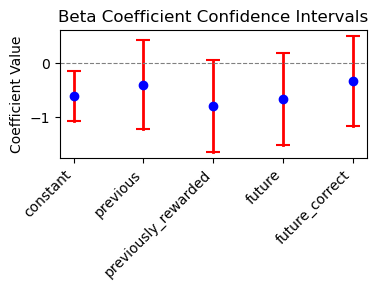

In [214]:
m = model['fit']
conf_int = m.conf_int(alpha=0.05) # 95% confidence interval
coefs = m.params

# Create a DataFrame for easier plotting (optional but good practice)
results_df = pd.DataFrame({
        'coef': coefs,
        'lower_ci': conf_int[:, 0],
        'upper_ci': conf_int[:, 1]
    }, index=["constant", "previous", "previously_rewarded", "future", "future_correct"]) # Adjust index names as per your model

# Plotting
fig, ax = plt.subplots(figsize=(4, 3))

# Plot coefficients as points
ax.scatter(results_df.index, results_df['coef'], color='blue', zorder=2, label='Coefficient Estimates')

# Plot confidence intervals as error bars or lines
for i, row in results_df.iterrows():
    ax.plot([row.name, row.name], [row['lower_ci'], row['upper_ci']], color='red', linestyle='-', linewidth=2, zorder=1)
    ax.scatter(row.name, row['lower_ci'], marker='_', s=100, color='red', zorder=1)
    ax.scatter(row.name, row['upper_ci'], marker='_', s=100, color='red', zorder=1)

ax.axhline(y=0, color='gray', linestyle='--', linewidth=0.8) # Reference line at zero
ax.set_ylabel('Coefficient Value')
ax.set_title('Beta Coefficient Confidence Intervals')
#ax.legend()
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [196]:
X.shape

(224, 4)

In [193]:
model = do_GLM_subprocess(np.hstack((X[:,:2],X[:,3:],Y)))

In [194]:
model['fit'].summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                 Generalized Linear Model Regression Results                  
==============================================================================
Dep. Variable:                      y   No. Observations:                  224
Model:                            GLM   Df Residuals:                      220
Model Family:                Binomial   Df Model:                            3
Link Function:                  Logit   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -123.08
Date:                Wed, 22 Oct 2025   Deviance:                       246.15
Time:                        16:18:02   Pearson chi2:                     224.
No. Iterations:                     4   Pseudo R-squ. (CS):            0.02545
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.7238      0.221     -3.276      0.001      -1.157      -0.291
x1            -0.3038      0.417     -0.729      0.466      -1.121       0.513
x2            -0.7687      0.436     -1.763      0.078      -1.623       0.086
x3            -0.5755      0.394     -1.462      0.144      -1.347       0.196
==============================================================================
"""

In [172]:
tally_dict[('lewis20240105_.nwb', '02_Rev2Session1',98)]

[(array([1.70448251e+09, 1.70448251e+09]), 2),
 (array([1.70448251e+09, 1.70448251e+09]), 3),
 (array([1.70448251e+09, 1.70448251e+09]), 2),
 (array([1.70448251e+09, 1.70448251e+09]), 3)]

In [42]:
arm_identities_animal

[[2, 2, 2],
 [2, 2],
 [1],
 [1],
 [2],
 [2, 2, 2, 2, 3],
 [2, 2, 2, 2, 3],
 [2],
 [2, 2],
 [2],
 [2, 2],
 [2],
 [2, 2],
 [2],
 [3, 3, 3],
 [2],
 [3],
 [3],
 [0, 4],
 [3, 4, 2, 2],
 [1],
 [4, 2, 4, 2],
 [2],
 [4, 4, 2],
 [2],
 [4, 4],
 [3],
 [3],
 [2],
 [2],
 [2],
 [2, 2],
 [2, 2],
 [2],
 [2],
 [0],
 [3, 2],
 [2],
 [2, 2],
 [2, 2, 2],
 [2, 2, 2, 2, 2, 2, 2],
 [2],
 [3],
 [2],
 [2, 2, 2],
 [2],
 [0],
 [0, 0],
 [4],
 [2, 2],
 [2, 2, 2, 2, 2, 3],
 [4],
 [2],
 [2],
 [2, 2],
 [2, 2],
 [4, 4],
 [2, 2, 2, 2],
 [1, 1]]

In [41]:
info_animal

[['lewis20240105_.nwb', '02_Rev2Session1', [42, 42, 42]],
 ['lewis20240105_.nwb', '02_Rev2Session1', [50, 50]],
 ['lewis20240105_.nwb', '02_Rev2Session1', [66]],
 ['lewis20240105_.nwb', '02_Rev2Session1', [66]],
 ['lewis20240105_.nwb', '02_Rev2Session1', [70]],
 ['lewis20240105_.nwb', '02_Rev2Session1', [98, 98, 98, 98, 98]],
 ['lewis20240105_.nwb', '02_Rev2Session1', [98, 98, 98, 98, 98]],
 ['lewis20240105_.nwb', '04_Rev2Session2', [9]],
 ['lewis20240105_.nwb', '06_Rev2Session3', [22, 22]],
 ['lewis20240105_.nwb', '08_Rev2Session4', [16]],
 ['lewis20240105_.nwb', '08_Rev2Session4', [20, 20]],
 ['lewis20240106_.nwb', '02_Rev2Session1', [39]],
 ['lewis20240106_.nwb', '04_Rev2Session2', [71, 71]],
 ['lewis20240106_.nwb', '06_Rev2Session3', [44]],
 ['lewis20240106_.nwb', '08_Rev2Session4', [13, 13, 13]],
 ['lewis20240106_.nwb', '08_Rev2Session4', [18]],
 ['lewis20240107_.nwb', '02_Rev2Session1', [47]],
 ['lewis20240107_.nwb', '02_Rev2Session1', [47]],
 ['lewis20240107_.nwb', '06_Rev2Sessi

In [175]:
tally_dict

{('lewis20240105_.nwb',
  '02_Rev2Session1',
  42): [(0, array([1.70448095e+09, 1.70448095e+09]), 2)],
 ('lewis20240105_.nwb',
  '02_Rev2Session1',
  50): [(0, array([1.70448114e+09, 1.70448114e+09]), 2)],
 ('lewis20240105_.nwb',
  '02_Rev2Session1',
  66): [(0, array([1.70448157e+09, 1.70448157e+09]), 1),
  (1, array([1.70448157e+09, 1.70448157e+09]), 1)],
 ('lewis20240105_.nwb',
  '02_Rev2Session1',
  70): [(0, array([1.70448169e+09, 1.70448169e+09]), 2)],
 ('lewis20240105_.nwb',
  '02_Rev2Session1',
  98): [(0, array([1.70448251e+09, 1.70448251e+09]), 2),
  (0, array([1.70448251e+09, 1.70448251e+09]), 3),
  (1, array([1.70448251e+09, 1.70448251e+09]), 2),
  (1, array([1.70448251e+09, 1.70448251e+09]), 3)],
 ('lewis20240105_.nwb',
  '04_Rev2Session2',
  9): [(0, array([1.70448525e+09, 1.70448525e+09]), 2)],
 ('lewis20240105_.nwb',
  '06_Rev2Session3',
  22): [(0, array([1.70448949e+09, 1.70448949e+09]), 2)],
 ('lewis20240105_.nwb',
  '08_Rev2Session4',
  16): [(0, array([1.70449394e+

In [6]:
from spyglass.shijiegu.load import load_decode
from spyglass.shijiegu.decodeHelpers import session2position_name
from spyglass.shijiegu.ripple_add_replay import select_subset_helper, select_subset_helper_pd
from spyglass.shijiegu.Analysis_SGU import get_linearization_map
from spyglass.common.common_position import TrackGraph, IntervalLinearizedPosition, IntervalPositionInfo

In [16]:
animal = "lewis"

In [17]:
loaded_data = load_remote_animal_figure4(
        animal, list_of_days_animals[animal],
        encoding_set_animals[animal],
        classifier_param_name_animals[animal],
        proportion = proportion, use_1d = use_1d)
    
(all_info_animal, info_animal,
     time_intervals_animal, arm_identities_animal
        ) = (loaded_data['all_info_animal'], loaded_data['info_animal'],
             loaded_data['time_intervals_animal'], loaded_data['arm_identities_animal'])

Successfully loaded data from '/stelmo/shijie/change_of_mind_analysis/figure4/lewis_2Dheadspeed_above_4_default_decoding_gpu_4armMaze_20240105_20240110_p0.1_use1d1.pkl':


In [135]:
time_intervals_animal

[[array([1.70448095e+09, 1.70448095e+09]),
  array([1.70448095e+09, 1.70448095e+09]),
  array([1.70448095e+09, 1.70448095e+09])],
 [array([1.70448114e+09, 1.70448114e+09]),
  array([1.70448114e+09, 1.70448114e+09])],
 [array([1.70448157e+09, 1.70448157e+09])],
 [array([1.70448157e+09, 1.70448157e+09])],
 [array([1.70448169e+09, 1.70448169e+09])],
 [array([1.70448251e+09, 1.70448251e+09]),
  array([1.70448251e+09, 1.70448251e+09]),
  array([1.70448251e+09, 1.70448251e+09]),
  array([1.70448251e+09, 1.70448251e+09]),
  array([1.70448251e+09, 1.70448251e+09])],
 [array([1.70448251e+09, 1.70448251e+09]),
  array([1.70448251e+09, 1.70448251e+09]),
  array([1.70448251e+09, 1.70448251e+09]),
  array([1.70448251e+09, 1.70448251e+09]),
  array([1.70448251e+09, 1.70448251e+09])],
 [array([1.70448525e+09, 1.70448525e+09])],
 [array([1.70448949e+09, 1.70448949e+09]),
  array([1.70448949e+09, 1.70448949e+09])],
 [array([1.70449394e+09, 1.70449394e+09])],
 [array([1.70449407e+09, 1.70449407e+09]),
 

In [32]:
info_animal

[['lewis20240105_.nwb', '02_Rev2Session1', [42, 42, 42]],
 ['lewis20240105_.nwb', '02_Rev2Session1', [50, 50]],
 ['lewis20240105_.nwb', '02_Rev2Session1', [66]],
 ['lewis20240105_.nwb', '02_Rev2Session1', [66]],
 ['lewis20240105_.nwb', '02_Rev2Session1', [70]],
 ['lewis20240105_.nwb', '02_Rev2Session1', [98, 98, 98, 98, 98]],
 ['lewis20240105_.nwb', '02_Rev2Session1', [98, 98, 98, 98, 98]],
 ['lewis20240105_.nwb', '04_Rev2Session2', [9]],
 ['lewis20240105_.nwb', '06_Rev2Session3', [22, 22]],
 ['lewis20240105_.nwb', '08_Rev2Session4', [16]],
 ['lewis20240105_.nwb', '08_Rev2Session4', [20, 20]],
 ['lewis20240106_.nwb', '02_Rev2Session1', [39]],
 ['lewis20240106_.nwb', '04_Rev2Session2', [71, 71]],
 ['lewis20240106_.nwb', '06_Rev2Session3', [44]],
 ['lewis20240106_.nwb', '08_Rev2Session4', [13, 13, 13]],
 ['lewis20240106_.nwb', '08_Rev2Session4', [18]],
 ['lewis20240107_.nwb', '02_Rev2Session1', [47]],
 ['lewis20240107_.nwb', '02_Rev2Session1', [47]],
 ['lewis20240107_.nwb', '06_Rev2Sessi

In [33]:
arm_identities_animal

[[2, 2, 2],
 [2, 2],
 [1],
 [1],
 [2],
 [2, 2, 2, 2, 3],
 [2, 2, 2, 2, 3],
 [2],
 [2, 2],
 [2],
 [2, 2],
 [2],
 [2, 2],
 [2],
 [3, 3, 3],
 [2],
 [3],
 [3],
 [0, 4],
 [3, 4, 2, 2],
 [1],
 [4, 2, 4, 2],
 [2],
 [4, 4, 2],
 [2],
 [4, 4],
 [3],
 [3],
 [2],
 [2],
 [2],
 [2, 2],
 [2, 2],
 [2],
 [2],
 [0],
 [3, 2],
 [2],
 [2, 2],
 [2, 2, 2],
 [2, 2, 2, 2, 2, 2, 2],
 [2],
 [3],
 [2],
 [2, 2, 2],
 [2],
 [0],
 [0, 0],
 [4],
 [2, 2],
 [2, 2, 2, 2, 2, 3],
 [4],
 [2],
 [2],
 [2, 2],
 [2, 2],
 [4, 4],
 [2, 2, 2, 2],
 [1, 1]]

In [162]:
arm_identities_animal[16]

[3]

In [163]:
arm_identities_animal[17]

[3]

In [156]:
ind = 50

In [157]:
print(info_animal[ind], arm_identities_animal[ind])

['lewis20240110_.nwb', '04_Rev2Session2', [17, 17, 17, 17, 17, 17]] [2, 2, 2, 2, 2, 3]


In [158]:
nwb_copy_file_name, session_name, trialID = info_animal[ind]


# 1.
decode = load_decode(nwb_copy_file_name,session_name,'default_decoding_gpu_4armMaze','2Dheadspeed_above_4')
position_axis = np.array(decode.coords['position'])

In [159]:
q = {"nwb_file_name": nwb_copy_file_name,
        "epoch":int(session_name[:2]),
        "proportion":str(proportion)}
    
log_df = ChangeofMind().fetch1_dataframe(q)

[2025-10-22 11:03:07,011][WARNING]: Skipped checksum for file with hash: 4966fca3-5add-6507-a578-c07eca58e93d, and path: /stelmo/nwb/analysis/lewis20240110/lewis20240110_YVZ4HOMCDS.nwb


In [160]:
log_df[log_df.change_of_mind]

,timestamp_H,Home,timestamp_O,OuterWellIndex,rewardNum,change_of_mind,CoMMaxProportion,initial_choice,initial_time,proportion_arm1,proportion_arm2,proportion_arm3,proportion_arm4,CoMNum_by_time,CoMNum_by_arm,current,future_H,future_O,past,past_reward
id,,,,,,,,,,,,,,,,,,,,
12,1.704916e+09,1.0,1.704916e+09,1.0,2.0,True,0.782806,4.0,1.704916e+09,0.000000,0.782806,0.000000,0.165771,4,2,1.0,1.0,3.0,3.0,3.0
15,1.704916e+09,1.0,1.704916e+09,2.0,2.0,True,0.435658,1.0,1.704916e+09,0.435658,0.000000,0.000000,0.000000,1,1,2.0,2.0,4.0,4.0,1.0
17,1.704916e+09,1.0,1.704916e+09,3.0,2.0,True,0.976399,1.0,1.704916e+09,0.976399,0.000000,0.000000,0.000000,1,1,3.0,3.0,1.0,4.0,4.0
18,1.704916e+09,1.0,1.704916e+09,1.0,2.0,True,0.106597,2.0,1.704916e+09,0.000000,0.106597,0.000000,0.000000,1,1,1.0,1.0,2.0,3.0,3.0
22,1.704916e+09,1.0,1.704916e+09,1.0,2.0,True,0.957479,2.0,1.704916e+09,0.000000,0.957479,0.000000,0.000000,1,1,1.0,1.0,4.0,3.0,3.0
24,1.704916e+09,1.0,1.704916e+09,2.0,2.0,True,0.768637,2.0,1.704916e+09,0.000000,0.294092,0.768637,0.000000,2,2,2.0,2.0,4.0,4.0,1.0
26,1.704916e+09,1.0,1.704916e+09,3.0,2.0,True,0.448639,1.0,1.704916e+09,0.448639,0.334019,0.000000,0.000000,2,2,3.0,3.0,4.0,4.0,4.0
29,1.704916e+09,1.0,1.704916e+09,2.0,2.0,True,0.790893,4.0,1.704916e+09,0.000000,0.000000,0.000000,0.790893,1,1,2.0,2.0,4.0,1.0,1.0
35,1.704916e+09,1.0,1.704916e+09,4.0,2.0,True,0.131716,3.0,1.704916e+09,0.000000,0.000000,0.131716,0.000000,1,1,4.0,4.0,3.0,2.0,2.0


In [46]:
from spyglass.shijiegu.changeOfMind_figures.figure4d import arm_to_features

In [48]:
arm_to_features(np.array([1,2,3,4]),feature_dict = {"recent":1,
                        "recent_reward":4,
                        "final_choice":2,
                        "future_correct":2})

(array([[ True, False, False, False],
        [False, False,  True,  True],
        [False, False, False, False],
        [False,  True, False, False]]),
 [array(False), array(True), array(True), array(True)])

In [339]:
t0, t1 = time_intervals_animal[ind][0]

timestamp_H         1704837183.325913
Home                              1.0
timestamp_O         1704837204.335067
OuterWellIndex                    4.0
rewardNum                         2.0
change_of_mind                   True
CoMMaxProportion             0.828244
initial_choice                    1.0
initial_time        1704837192.212236
proportion_arm1              0.306349
proportion_arm2              0.828244
proportion_arm3                   0.0
proportion_arm4                   0.0
CoMNum_by_time                      3
CoMNum_by_arm                       2
current                           4.0
future_H                          4.0
future_O                          1.0
past                              3.0
past_reward                       2.0
Name: 14, dtype: object

In [177]:
# 2. get decode and animal head direction
position_name = session2position_name(nwb_copy_file_name, session_name)
position_info = (IntervalPositionInfo() & {
                'nwb_file_name':nwb_copy_file_name,
                'interval_list_name':position_name,
                'position_info_param_name':'default_decoding'}).fetch1_dataframe()
position_info1d = (IntervalLinearizedPosition() & {
                'nwb_file_name':nwb_copy_file_name,
                'interval_list_name':position_name,
                'position_info_param_name':'default_decoding'}).fetch1_dataframe() #for debug use only


[2025-10-22 14:56:53,290][WARNING]: Skipped checksum for file with hash: 7c7e9aea-6b5b-6d44-d2b7-9e5dc7d8f455, and path: /stelmo/nwb/analysis/lewis20240110/lewis20240110_KEQJO0PVHX.nwb
[2025-10-22 14:56:53,311][WARNING]: Skipped checksum for file with hash: 7c7e9aea-6b5b-6d44-d2b7-9e5dc7d8f455, and path: /stelmo/nwb/analysis/lewis20240110/lewis20240110_KEQJO0PVHX.nwb
[2025-10-22 14:56:53,318][WARNING]: Skipped checksum for file with hash: 7c7e9aea-6b5b-6d44-d2b7-9e5dc7d8f455, and path: /stelmo/nwb/analysis/lewis20240110/lewis20240110_KEQJO0PVHX.nwb
[14:57:02][WARNING] Spyglass: Deprecation: this class has been moved out of spyglass.common.common_position
	IntervalLinearizedPosition -> spyglass.linearization.v0.main.IntervalLinearizedPosition
Please use the new location.
	IntervalLinearizedPosition -> spyglass.linearization.v0.main.IntervalLinearizedPosition
Please use the new location.
[2025-10-22 14:57:02,891][WARNING]: Skipped checksum for file with hash: 6ba48a1e-2633-a8e4-fe68-928f

In [178]:
position_info1d

,linear_position,track_segment_id,projected_x_position,projected_y_position
time,,,,
1.704916e+09,NaN,0,NaN,NaN
1.704916e+09,NaN,0,NaN,NaN
1.704916e+09,NaN,0,NaN,NaN
1.704916e+09,NaN,0,NaN,NaN
1.704916e+09,NaN,0,NaN,NaN
...,...,...,...,...
1.704918e+09,88.745248,1,215.631138,145.424391
1.704918e+09,88.721903,1,215.630102,145.447714
1.704918e+09,88.698557,1,215.629065,145.471036


In [331]:
# 4. Get animal head direction
head_orientation = np.array(pos2d_subset.head_orientation)
head_orientation_unit = np.hstack((np.cos(head_orientation).reshape((-1,1)),np.sin(head_orientation).reshape((-1,1)))) #unit vector

# Get max_posterior_2d - animal location
animal_location = np.hstack((np.array(pos2d_subset.head_position_x).reshape(-1,1),np.array(pos2d_subset.head_position_y).reshape(-1,1)))
displacement_unit = max_posterior_2d - animal_location
displacement_unit = displacement_unit / np.linalg.norm(displacement_unit, axis = 1).reshape((-1,1))

# finally: return degree
dot_product = [np.dot(head_orientation_unit[i],displacement_unit[i].T) for i in range(displacement_unit.shape[0])]
angle = np.degrees(np.arccos(np.clip(dot_product, -1.0, 1.0)))



In [332]:
angle

array([14.44713613, 14.48218834, 14.51722652, 14.55225064, 14.5872607 ,
       14.62225669, 14.65723861, 14.69220645, 14.72716019, 14.76209984,
       14.79702538, 14.83193681, 14.86683412, 14.90171729, 14.93658634,
       14.97144174, 15.00648324, 15.07571997, 15.11071878, 15.14550336,
       15.18027325, 15.21502896, 15.24977046, 15.28449776, 15.31921085,
       15.35390973, 15.38859437, 14.52662663, 12.62564912, 11.61687587])

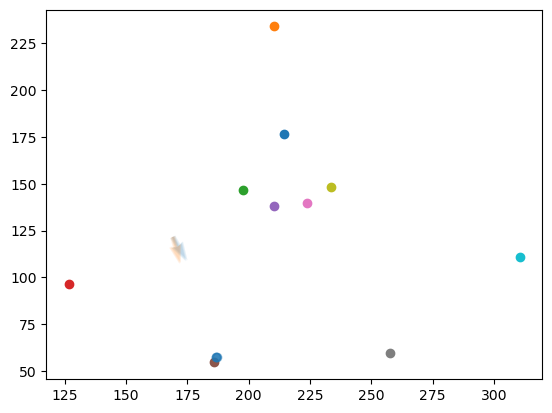

In [334]:
fig, ax = plt.subplots()

for key in nodes:
     node = nodes[key]
     for n in node:
         ax.scatter(n[0],n[1])
ax.scatter(max_posterior_2d[::10,0] + np.random.rand(len(max_posterior_2d[::10,0]))*.1,
            max_posterior_2d[::10,1] + + np.random.rand(len(max_posterior_2d[::10,0]))*.1, alpha = 0.5)

ax.quiver(animal_location[::10,0],animal_location[::10,1],
           head_orientation_unit[::10,0],head_orientation_unit[::10,1],color = 'C0',alpha = 0.1)
ax.quiver(animal_location[::10,0],animal_location[::10,1],
           displacement_unit[::10,0],displacement_unit[::10,1],color = 'C1',alpha = 0.1)


# Invert the y-axis (make it upside down)
#ax.invert_yaxis()

array([225.12560103, 136.2734064 ])

In [ ]:
#plt.plot(max_posterior_1d)
for key in nodes:
    node = nodes[key]
    for n in node:
        plt.scatter(n[0],n[1])
plt.scatter(max_posterior_2d[:,0], max_posterior_2d[:,1])